In [ ]:
import pandas as pd

In [ ]:
df = pd.read_parquet('dados_clones.parquet')
df

,p2o_master_id,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
0,10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
1,10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
2,10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
3,10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
4,10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso
...,...,...,...,...,...,...,...,...,...
1048714,10230117,84.14,Yoda,181.03,Tipo 2,Tipo 1,Tipo 2,51.3,Apto
1048715,10230118,83.10,Yoda,180.62,Tipo 2,Tipo 1,Tipo 3,3.3,Apto
1048716,10230119,83.63,Obi-Wan Kenobi,180.54,Tipo 5,Tipo 2,Tipo 5,40.1,Apto
1048717,10230120,83.02,Shaak Ti,180.06,Tipo 1,Tipo 4,Tipo 1,11.2,Apto


In [ ]:
print(df.columns)

Index(['p2o_master_id', 'Massa(em kilos)', 'General Jedi encarregado',
       'Estatura(cm)', 'Distância Ombro a ombro', 'Tamanho do crânio',
       'Tamanho dos pés', 'Tempo de existência(em meses)', 'Status '],
      dtype='object')


In [ ]:
# Para realizar o replace
df['General Jedi encarregado'].unique()

array(['Yoda', 'Shaak Ti', 'Obi-Wan Kenobi', 'Aayla Secura', 'Mace Windu'],
      dtype=object)

In [ ]:
# Para realizar o replace
df['Distância Ombro a ombro'].unique()

array(['Tipo 4', 'Tipo 3', 'Tipo 2', 'Tipo 1', 'Tipo 5'], dtype=object)

In [ ]:
features = ['Massa(em kilos)','General Jedi encarregado','Estatura(cm)','Distância Ombro a ombro','Tamanho do crânio','Tamanho dos pés','Tempo de existência(em meses)']
target = 'Status '

In [ ]:
from sklearn import tree

model = tree.DecisionTreeClassifier()

In [ ]:
X = df[features]
y = df[target]

In [ ]:
X = X.replace({
    'Yoda':1,'Shaak Ti':2,'Obi-Wan Kenobi':3,'Aayla Secura':4,'Mace Windu':5,
    'Tipo 4':4,'Tipo 3':3,'Tipo 2':2,'Tipo 1':1,'Tipo 5':5
})

In [ ]:
# Modelo

model.fit(X=X, y=y)

DecisionTreeClassifier()

[Text(0.7142857142857143, 0.9, 'Massa(em kilos) <= 83.405\ngini = 0.189\nsamples = 1048719\nvalue = [938193, 110526]\nclass = Apto'),
 Text(0.5714285714285714, 0.7, 'General Jedi encarregado <= 2.5\ngini = 0.436\nsamples = 344571\nvalue = [234045, 110526]\nclass = Apto'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'Estatura(cm) <= 180.555\ngini = 0.485\nsamples = 188535\nvalue = [78009, 110526]\nclass = Defeituoso'),
 Text(0.2857142857142857, 0.3, 'Estatura(cm) <= 180.245\ngini = 0.28\nsamples = 132896\nvalue = [22370, 110526]\nclass = Defeituoso'),
 Text(0.14285714285714285, 0.1, '\n  (...)  \n'),
 Text(0.42857142857142855, 0.1, '\n  (...)  \n'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 55639\nvalue = [55639, 0]\nclass = Apto'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 156036\nvalue = [156036, 0]\nclass = Apto'),
 Text(0.8571428571428571, 0.7, 'gini = 0.0\nsamples = 704148\nvalue = [704148, 0]\nclass = Apto'),
 Text(0.7857142857

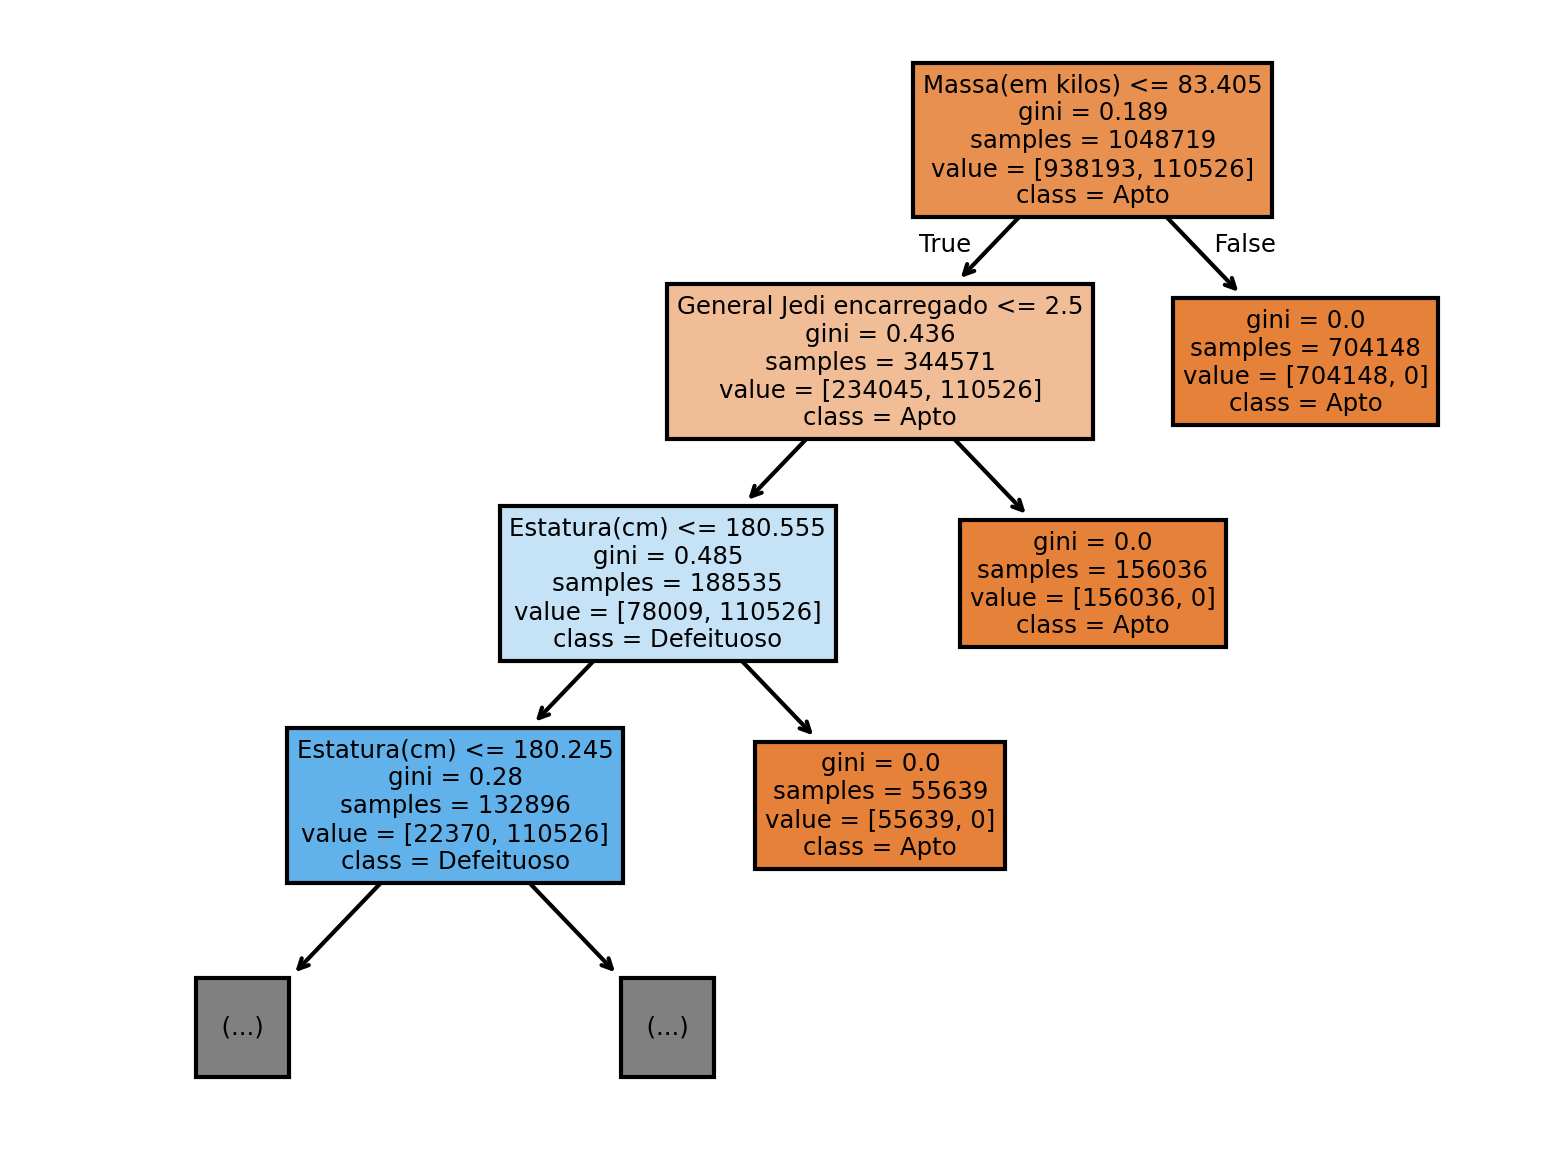

In [ ]:
# Mostrar a árvore
import matplotlib.pyplot as plt

plt.figure(dpi=300)

tree.plot_tree(
              model,
               feature_names=features,
               class_names=model.classes_,
               filled=True,
               max_depth=3)

In [ ]:
features = ['Massa(em kilos)','Estatura(cm)']
df.groupby('Status ')[features].mean()


# As médias não mostram aparentemente qual seria o problema
# Ávore faz análises combinando os nós

,Massa(em kilos),Estatura(cm)
Status,,
Apto,83.765887,180.605545
Defeituoso,83.200134,180.400186
